# `Matplotlib with OpenCV`

In [8]:
%pip install matplotlib pandas numpy opencv-python

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.3 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/9.3 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.3 MB 1.1 MB/s eta 0:00:08
   ---------- ----------------------------- 2.4/9.3 MB 2.3 MB/s eta 0:00:04
   ---------- ----------------------------- 2.4/9.3 MB 2.3 MB/s eta 0:00:04
   ---------- ----------------------------- 2.4/9.3 MB 2.3 MB/s eta 0:00:04
   ----------- ---------------------------- 2.6/9.3 MB 1.5 MB/s eta 0:00:05
   --------------- ------------------------ 3.7/9.3 MB 2.0 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.3 MB 2.0 MB/s eta 0:00:03
   ---------------- ------------------

In [ ]:
# For image - 2
#type:ignore 

import cv2

img2 = cv2.imread("..\\fol\\parrot.jpg")

""" Creating a by removing background of the image """
# Converting to grayscale
gray = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

# Applying threshold
# median blur
blur = cv2.medianBlur(gray,5)
# Applying threshold to remove noise
ret,thresh = cv2.threshold(blur,220,255,cv2.THRESH_BINARY_INV)
# creating a mask
mask = cv2.erode(thresh,None,2)

back_rem_img = cv2.bitwise_and(img2,img2,mask=mask)
cv2.imshow("Background Removed Image",back_rem_img)
cv2.imwrite("back_rem_img.png",back_rem_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


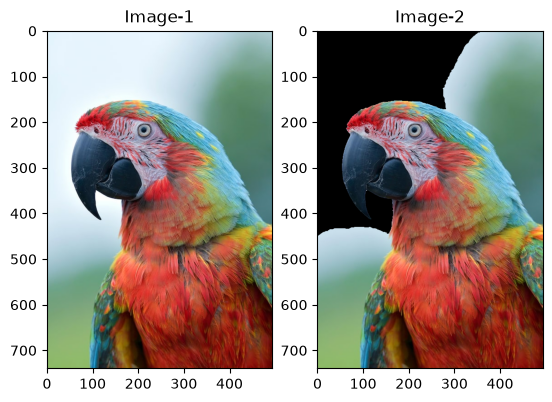

In [ ]:
# Now using matplotlib 
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread('..\\fol\\parrot.jpg')
img2 = cv2.imread('..\\fol\\back_rem_img.png')

fig,(ax1,ax2) = plt.subplots(1,2)
ax1.imshow(cv2.cvtColor(img1,cv2.COLOR_BGR2RGB))  #NOTE need to convert the bgr to rgb
ax1.set_title("Image-1")
ax2.imshow(cv2.cvtColor(img2,cv2.COLOR_BGR2RGB))
ax2.set_title("Image-2")
plt.show()

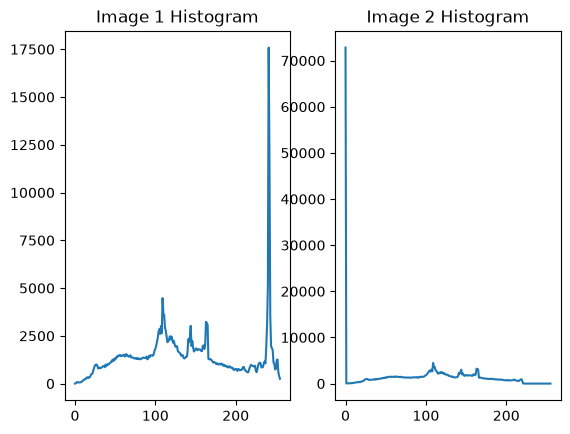

In [43]:
# Plotting the histogram of an images
fig,(ax1,ax2) = plt.subplots(1,2)

grayed_img1 = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
grayed_img2 = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

# hist = cv2.calcHist([grayed_img1], [0], None, [256], [0, 256])
hist = cv2.calcHist(
    [grayed_img1],
    [0],
    None,
    [256],
    [0, 256]
)
ax1.plot(hist)
ax1.set_title('Image 1 Histogram')

hist2 = cv2.calcHist(
    [grayed_img2],
    [0],
    None,
    [256],
    [0, 256]
)
ax2.plot(hist2)
ax2.set_title('Image 2 Histogram')

plt.show()

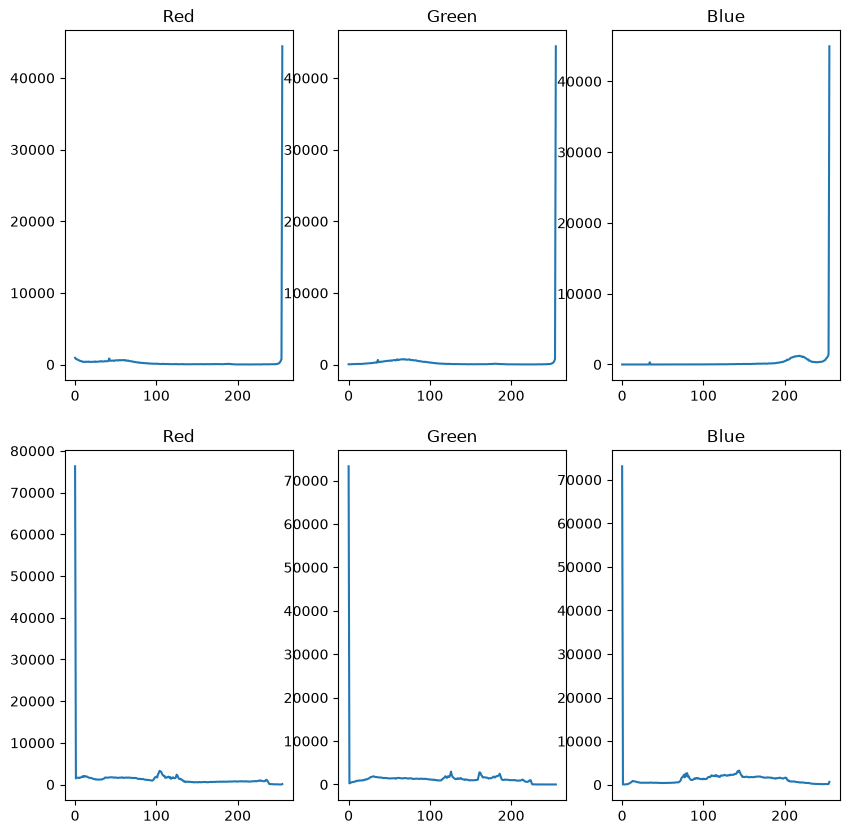

In [ ]:
# Plotting the histogram on different channels of an image
#type: ignore
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread('..\\fol\\apple.png')
img2 = cv2.imread('..\\fol\\back_rem_img.png')

fig,ax = plt.subplots(2,3,figsize=(10,10))
hist1 = cv2.calcHist(
    [img1],
    [0],
    None,
    [256],
    [0,256]
)

ax[0,0].plot(hist1)
ax[0,0].set_title('Red')

hist2 = cv2.calcHist(
    [img1],
    [1],
    None,
    [256],
    [0,256]
)

ax[0,1].plot(hist2)
ax[0,1].set_title('Green')

hist3 = cv2.calcHist(
    [img1],
    [2],
    None,
    [256],
    [0,256]
)

ax[0,2].plot(hist3)
ax[0,2].set_title('Blue')

hist4 = cv2.calcHist(
    [img2],
    [0],
    None,
    [256],
    [0,256]
)

hist5 = cv2.calcHist(
    [img2],
    [1],
    None,
    [256],
    [0,256]
)

hist6 = cv2.calcHist(
    [img2],
    [2],
    None,
    [256],
    [0,256]
)

ax[1,0].plot(hist4)
ax[1,0].set_title('Red')
ax[1,1].plot(hist5)
ax[1,1].set_title('Green')
ax[1,2].plot(hist6) 
ax[1,2].set_title('Blue')
plt.show()



# `Morphological transformations ` 
are set of operations that process images based on their shape. These operations are performed on binary images,such as those obtained by thresholding.Following are the morphological transformations:
1. **Erosion** : It **shrinks the boundaries** of the foreground object. It applies a kernel over the image and **if all pixels under the kernel are of the same value pixels(eg. white) central pixel is set to that pixel(white)**,otherwise black.

2. **Dilation** : It **expands the boundaries** of the foreground object. It applies a kernel over the image and **if atleast one pixel under the kernel is white, the center pixel is set to white,otherwise black.**

3. **Opening** : It consists of **erosion followed by dilation**. It is used to **remove noise and small objects in a binary image** or smooth the contours of an object.

4. **Closing** : It consists of dilation followed by erosion. It is used to **fill small holes in a binary image** or smooth the contours of an object.

5. **Gradient** : It is used to detect the edges of an object. It is applied on grayscale images.

In [ ]:
import cv2
import numpy as np

img = cv2.imread('..\\fol\\apple.png',0) # this will convert it to grayscale

# define the kernel
kernel = np.ones((3,3),np.uint8)

# Apply the erosion
erosion = cv2.erode(img,kernel,1)
cv2.imwrite("erroded_apple.png",erosion) #YOU will see that images has reduced white patches in it then the prior

cv2.imshow('Image',img)
cv2.imshow('Erosion',erosion)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
# applying the Dilation
import cv2

img = cv2.imread('..\\fol\\apple.png',0)
kernel = np.ones((3,3),np.uint8)

# Applying the dilation
dilation = cv2.dilate(img,kernel,iterations = 1)

cv2.imshow('Original',img) 
cv2.imshow('Dilation',dilation)
cv2.imwrite("dilated.png",dilation) # YOU will see that the image has more white patches that the original one
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
# k =np.ones((15,15),np.uint8)
# dilation = cv2.dilate(img,k,iterations = 1)

# cv2.imshow('Original',img) 
# cv2.imshow('Dilation',dilation)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

""" 
See how changing the kernel size affects the dilation and erosion
"""

In [66]:
# opening and closing 
kernel = np.ones((3,3),np.uint8)

# opening
opened = cv2.morphologyEx(img,cv2.MORPH_OPEN,kernel)

# closing
closed = cv2.morphologyEx(img,cv2.MORPH_CLOSE,kernel)


cv2.imshow("Original",img)
cv2.imshow("Erroded",erosion)
cv2.imshow("Dilation",dilation)
cv2.imshow("Opened",opened)  # this results the best now reduced white patch no more black patches 
cv2.imshow("Closed",closed)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [74]:
# gradient
gradient = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=5)
cv2.imshow("Gradient",gradient)

canny = cv2.Canny(img,100,200)
cv2.imshow("Canny",canny)
cv2.waitKey(0)
cv2.destroyAllWindows()

# `Smoothing and Blurring`
Used in noise reduction, edge detection, and sharpening. There are several types of smoothing and blurring techniques as follows:

1. **Gaussian Blur** :It is used to **blur an image and reduce noise**. Apply a Gaussian kernel that **emphasizes the central area more than the surrounding areas**.

2. **Median Blur** :It is used to **remove salt and pepper noise from an image**. It works by replacing each **pixel with the median value of its neighbouring pixels**.

3. **Bilateral Blur** : It is used to  **smooth and image while preserving edges**. It works by applying a **gaussian filter to the pixels based on their spatial distance and intensity difference**.

4. **Box filter** : It is used to **blur an image and reduce noise**. It works by convolving the image with a **rectangular kernel, which averages the pixels within the kernel**.

5. **Mean blur** : It is used to **blur an image and reduce noise**. It defines the size of kernel that we want to use for mean filter. 

In [ ]:
# type: ignore
import cv2
img = cv2.imread('..\\fol\\apple.png')

# Applying the Gaussian Blur
blur = cv2.GaussianBlur(
    img,  #source image
    (5,5), #kernel size (width, height)
    0
)
cv2.imshow('Original Image', img)
cv2.imshow('Gaussian Blur', blur)

# Applying the median blur
blur = cv2.medianBlur(
    img,  #source image
    5 #kernel size in integer
)
cv2.imshow('Median Blur', blur)

# Applying the bilateral filter
blur = cv2.bilateralFilter(
    img,  #source image
    5, #diameter of the kernel
    171, #sigma color
    171, #sigma space
)
cv2.imshow('Bilateral Filter', blur)

# Applying the Box Filter
blur = cv2.boxFilter(
    img,  #source image
    -1, #the size of the kernel
    (5,5), #the anchor point
    normalize=True, #whether to normalize the kernel
)
cv2.imshow('Box Filter', blur)

# Applying mean blur
kernel_size = 5
kernel = np.ones((kernel_size,kernel_size),np.float32)/kernel_size**2

blur = cv2.filter2D(
    img,  #source image
    -1, #the size of the kernel
    kernel, #the kernel
)
cv2.imshow('Mean Blur', blur)

cv2.waitKey(0)  
cv2.destroyAllWindows()



# **Image Gradients**
Used to measure the **rate of change** of pixel values in an image. Useful for detecting **edges** and **corners**. Can be calculated using the **Sobel Filter**, **Scharr Filter** or **Laplacian Filter**.

1. **Sobel Filter** and **Scharr Filter** :used to calculate the first-order derivatives of an image, which represent the gradient in the x and y directions, respectively. These filters work by convolving the image with a small kernel that approximates the
derivative of the image.

2. **Laplacian Filter** : calculates the second-order derivative of an image, which represents the curvature of the image. This filter is useful for detecting edges and corners in an image


In [ ]:
import cv2
img = cv2.imread('..\\fol\\apple.png')
# Convert The image to grayscale
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# Calculate the horizontal and vertical sobel gradients
sobel_x = cv2.Sobel(
    gray,
    cv2.CV_64F,  ## ddepth
    1,           ## dx
    0,           ## dy
    ksize=3      ## ksize
)
sobel_y = cv2.Sobel(
    gray,
    cv2.CV_64F,  ## ddepth
    0,           ## dx
    1,           ## dy
    ksize=3      ## ksize
)

# Calculate the absolute value of the gradients
abs_grad_x = cv2.convertScaleAbs(sobel_x)
abs_grad_y = cv2.convertScaleAbs(sobel_y)

# Combine the gradients using the magnitude and direction
grad_mag = cv2.addWeighted(
    abs_grad_x,
    0.5,   ## alpha
    abs_grad_y,
    0.5,   ## beta
    0,     ## gamma
)

grad_dir = cv2.phase(
    sobel_x,
    sobel_y,
    angleInDegrees=True
)

# Display the results
cv2.imshow("Original Image",img)
cv2.imshow("Horizontal Gradient",abs_grad_x)
cv2.imshow("Vertical Gradient",abs_grad_y)
cv2.imshow("Gradient Magnitude",grad_mag)
cv2.imshow("Gradient Direction",grad_dir)
cv2.waitKey(0)
cv2.destroyAllWindows()

# `Edge detection` using OpenCV
It is a process of identifying the boundaries between objects in an image. In computer vision,edge detection is a fundamental step,in many tasks such as object detection, image segmentation, and feature extraction.

Several methods available for edge detection, including **Canny edge detection, Sobel operator, Laplacian of Gaussian(LoG) filter.**

1. **Sobel Operator** : It is a commonly used edge detection
filter in OpenCV. It calculates the **gradient of an image in the x and y directions and then combines the two gradients to produce an edge map.**
2. **Laplacian of Gaussian (LoG) Filter**: It is a second-order
derivative filter that is useful for detecting edges and corners in an image. It works by **first smoothing the image using a Gaussian filter**, and then calculating the **Laplacian of the smoothed image**. 
3. **Canny Edge Detection**: It is a widely used edge detection algorithm that is robust to noise and produces thin, well-defined edges. It works by **first smoothing the image using a Gaussian filter, then calculating the gradient magnitude and direction using the Sobel operator, and finally applying non-maximum suppression and hysteresis thresholding** to extract the edges.

**Edge Detection Parameters**: The performance of edge detection algorithms can be affected by various parameters such as the size of the filter kernel, the threshold values, and the hysteresis thresholding parameters. These parameters can be adjusted to achieve the desired edge detection results.

In [ ]:
# Sobel Operator
import cv2
img = cv2.imread("..\\fol\\parrot.jpg")

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Calculate the gradient using the Sobel operator
grad_x = cv2.Sobel(
    gray,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)
grad_y = cv2.Sobel(
    gray,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)

# Combine the gradients using the magnitude and direction
grad_mag = cv2.addWeighted(
    grad_x,
    0.5,
    grad_y,
    0.5,
    0
)

# Threshold the gradient magnitude to produce the binary edge map
edges = cv2.threshold(
    grad_mag,
    50, #threshold value
    255, #max value
    cv2.THRESH_BINARY
)[1]

# display the edge map
cv2.imshow("Original Image",img)
cv2.imshow("Edge Map",edges)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.imwrite("parrot_EdgeMap_sobel.jpg", edges)

True

In [ ]:
# Laplacian of Gaussian Filter
import cv2
import numpy as np

img = cv2.imread('..\\fol\\parrot.jpg',0)   # without converting to grayscale the result would be not that good

# define the kernel size and sigma
kernel_size = 5
sigma = 1.4

# Apply LoG filter
filtered_img = cv2.GaussianBlur(
    img,
    (kernel_size, kernel_size),
    sigma
)

# Apply LoG filter
filtered_img = cv2.Laplacian(
    filtered_img,
    cv2.CV_64F
)

# Normalize the filtered image
filtered_img = cv2.normalize(
    filtered_img, # input image
    None, # alpha
    0, # beta
    255, # norm_type
    cv2.NORM_MINMAX, # dtype
    cv2.CV_8U # output type
)

# Displaying the filtered images

cv2.imshow('img',img)
cv2.imshow('filtered_img',filtered_img)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.imwrite("Laplacian_edge.jpg", filtered_img)

True

In [ ]:
# Canny edge detection
img = cv2.imread("..\\fol\\parrot.jpg",0)

edges = cv2.Canny(
    img, # input image
    100, # lower threshold
    200 # upper threshold
)
cv2.imwrite("..\\fol\\canny_best_edge_det.jpg", edges)
cv2.imshow("edges", edges)
cv2.waitKey(0)
cv2.destroyAllWindows()

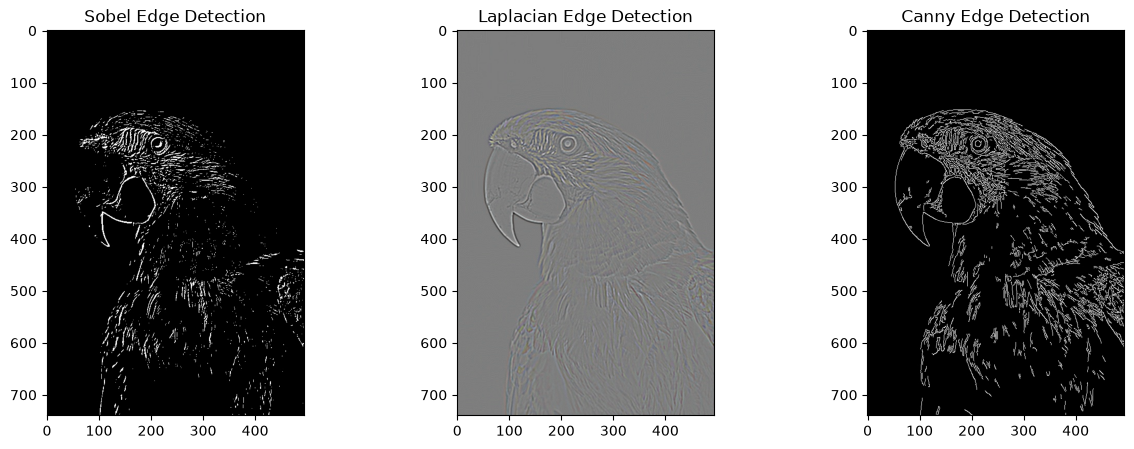

In [ ]:
import matplotlib.pyplot as plt

img1  = cv2.imread('..\\fol\\parrot_EdgeMap_sobel.jpg')
img2  = cv2.imread('..\\fol\\Laplacian_edge.jpg')
img3 = cv2.imread('..\\fol\\canny_best_edge_det.jpg')

fig,ax = plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(img1)
ax[0].set_title("Sobel Edge Detection")
ax[1].imshow(img2)
ax[1].set_title("Laplacian Edge Detection")
ax[2].imshow(img3)
ax[2].set_title("Canny Edge Detection")
plt.show()

In [114]:
import cv2
cap = cv2.VideoCapture(0)
while True:
    ret,frame = cap.read()
    if ret:
        edges = cv2.Canny(
            frame,
            100,200
        )
        cv2.imshow('Canny edges', edges)
        if cv2.waitKey(1)== ord('q'):
            break
    else:
        break

cap.release()
cv2.destroyAllWindows()